# 01 - 线性代数基础

> 配套教程：`01_math_foundations/01_linear_algebra.py`

## 本 Notebook 概览

| 章节 | 内容 | 关键概念 |
|------|------|----------|
| 1 | 标量、向量、矩阵、张量 | 数据结构维度理解 |
| 2 | 向量运算 | 点积、范数、几何意义 |
| 3 | 矩阵运算 | 乘法、转置、逆矩阵 |
| 4 | 线性方程组求解 | 矩阵表示与求解方法 |
| 5 | 特征值与特征向量 | 谱分解、几何解释 |
| 6 | 实战应用 | PCA 降维示例 |

**先决条件**：安装 `numpy`、`matplotlib`
```bash
pip install numpy matplotlib
```

In [15]:
# 环境设置
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

#plt.rcParams["font.sans-serif"] = ["SimHei"]  # 黑体，Linux可用WenQuanYi Zen Hei
plt.rcParams['font.sans-serif'] = ['WenQuanYi Zen Hei', 'DejaVu Sans']
plt.rcParams["axes.unicode_minus"] = False 

# 固定随机种子，保证可复现
np.random.seed(42)

print("NumPy 版本:", np.__version__)
print("✅ 环境准备完毕")


NumPy 版本: 2.2.6
✅ 环境准备完毕


## 1. 标量、向量、矩阵与张量

在机器学习中，数据通常用多维数组表示。理解这些基础数据结构是后续所有计算的基石。

| 概念 | 维度 | 数学记号 | NumPy 类型 | 例子 |
|------|------|----------|------------|------|
| **标量 (Scalar)** | 0-D | $a \in \mathbb{R}$ | `np.float64` | 温度 = 36.5 |
| **向量 (Vector)** | 1-D | $\mathbf{v} \in \mathbb{R}^n$ | `np.array([...])` | 特征向量 |
| **矩阵 (Matrix)** | 2-D | $\mathbf{M} \in \mathbb{R}^{m 	× n}$ | `np.array([[..],[..]])` | 数据集（样本 $	×$ 特征） |
| **张量 (Tensor)** | n-D | $\mathcal{T} \in \mathbb{R}^{d_1 	× d_2 	× \cdots}$ | `np.ndarray` | 图像 $(H 	× W 	× C)$ |

> **记号说明**
> - $\mathbb{R}$：实数集（Real numbers），如 1, 3.14, -2
> - $a \in \mathbb{R}$：标量 $a$ 是一个实数
> - $\mathbf{v} \in \mathbb{R}^n$：向量 $\mathbf{v}$ 是 $n$ 维实数向量（有 $n$ 个实数分量）
> - $\mathbf{M} \in \mathbb{R}^{m \times n}$：矩阵 $\mathbf{M}$ 有 $m$ 行 $n$ 列，共 $m \times n$ 个实数
> - $\mathcal{T} \in \mathbb{R}^{d_1 \times d_2 \times \cdots}$：张量 $\mathcal{T}$ 是 $d_1 \times d_2 \times \cdots$ 维的实数数组
> - $\mathbf{v}$（粗体）：表示向量或矩阵
> - $\mathcal{T}$（花体）：表示张量

### 思考
- 一张 $224 	× 224$ 的 RGB 图片对应几维张量？形状是什么？
- 批量处理 $32$ 张这样的图片，形状又是什么？


In [13]:
# ===== 1.1 创建不同维度的数据结构 =====

# 标量 (Scalar) - 0维
scalar = np.float64(3.14)
print(f"标量 scalar = {scalar}")
print(f"  维度 ndim : {scalar.ndim}")
print(f"  形状 shape: {scalar.shape}")
print()

# 向量 (Vector) - 1维
vector = np.array([1, 2, 3, 4])
print(f"向量 vector = {vector}")
print(f"  维度 ndim : {vector.ndim}")
print(f"  形状 shape: {vector.shape}")
print(f"  数据类型   : {vector.dtype}")
print()

# 矩阵 (Matrix) - 2维
matrix = np.array([
    [1, 2, 3],
    [4, 5, 6]
])
print(f"矩阵 matrix:")
print(matrix)
print(f"  维度 ndim : {matrix.ndim}")
print(f"  形状 shape: {matrix.shape}  (行, 列)")
print(f"  元素总数   : {matrix.size}")
print()

# 张量 (Tensor) - 3维 (模拟: 2张RGB图片, 每张2x3像素)
tensor = np.arange(12).reshape(2, 2, 3)  # (样本, 高, 宽, 通道) 简化
print(f"张量 tensor 形状: {tensor.shape}")
print(f"  维度 ndim : {tensor.ndim}")
print(f"  张量内容:")
print(tensor)


标量 scalar = 3.14
  维度 ndim : 0
  形状 shape: ()

向量 vector = [1 2 3 4]
  维度 ndim : 1
  形状 shape: (4,)
  数据类型   : int64

矩阵 matrix:
[[1 2 3]
 [4 5 6]]
  维度 ndim : 2
  形状 shape: (2, 3)  (行, 列)
  元素总数   : 6

张量 tensor 形状: (2, 2, 3)
  维度 ndim : 3
  张量内容:
[[[ 0  1  2]
  [ 3  4  5]]

 [[ 6  7  8]
  [ 9 10 11]]]


In [6]:
# ===== 1.2 特殊矩阵的创建 =====

# 零矩阵
zero_mat = np.zeros((3, 4))
print("零矩阵 zeros(3,4):")
print(zero_mat)
print()

# 单位矩阵
identity = np.eye(4)  # 4x4 单位矩阵
print("单位矩阵 eye(4):")
print(identity)
print()

# 全1矩阵
ones_mat = np.ones((2, 5))
print("全1矩阵 ones(2,5):")
print(ones_mat)
print()

# 对角矩阵
diag_mat = np.diag([10, 20, 30])
print("对角矩阵 diag([10,20,30]):")
print(diag_mat)
print()

# 随机矩阵 (常见于权重初始化)
random_mat = np.random.randn(3, 3)  # 标准正态分布
print("随机矩阵 randn(3,3):")
print(random_mat)


零矩阵 zeros(3,4):
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]

单位矩阵 eye(4):
[[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]

全1矩阵 ones(2,5):
[[1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]]

对角矩阵 diag([10,20,30]):
[[10  0  0]
 [ 0 20  0]
 [ 0  0 30]]

随机矩阵 randn(3,3):
[[ 0.49671415 -0.1382643   0.64768854]
 [ 1.52302986 -0.23415337 -0.23413696]
 [ 1.57921282  0.76743473 -0.46947439]]


## 2. 向量运算

向量是机器学习中最基本的数据单元。掌握向量的运算及其几何意义至关重要。

### 2.1 向量加法与数乘
- 加法：对应分量相加 $\mathbf{u} + \mathbf{v}$
- 数乘：每个分量乘以标量 $k\mathbf{v}$

### 2.2 点积（内积）
$$
\mathbf{u} \cdot \mathbf{v}
= \sum_i u_i v_i
= \lVert \mathbf{u} \rVert \, \lVert \mathbf{v} \rVert \cos	heta
$$

> **记号说明**
> - $\mathbf{u} \cdot \mathbf{v}$：点积（内积），两个向量的对应分量乘积之和
> - $\sum_i u_i v_i$：对所有分量 $i$ 求和，即 $u_1 v_1 + u_2 v_2 + \cdots + u_n v_n$
> - $\lVert \mathbf{u} \rVert$：向量 $\mathbf{u}$ 的模（长度/L2范数）
> - $\cos\theta$：两向量夹角的余弦值

点积的几何意义：衡量两个向量的相似度和方向关系。
- 点积 $> 0$：夹角 $< 90^\circ$，方向大致相同
- 点积 $= 0$：夹角 $= 90^\circ$，正交（垂直）
- 点积 $< 0$：夹角 $> 90^\circ$，方向大致相反

### 2.3 向量范数
- **L1 范数**（曼哈顿距离）：$\lVert \mathbf{v} \rVert_1 = \sum_i |v_i|$
- **L2 范数**（欧几里得距离）：$\lVert \mathbf{v} \rVert_2 = \sqrt{\sum_i v_i^2}$

范数用于正则化、距离计算和归一化。


In [7]:
# ===== 2.1 向量加法与数乘 =====
u = np.array([1, 2, 3])
v = np.array([4, 5, 6])
k = 2

print("向量 u:", u)
print("向量 v:", v)
print()

# 向量加法
add_result = u + v
print(f"u + v = {u} + {v} = {add_result}")

# 数乘
scaled = k * u
print(f"k * u = {k} x {u} = {scaled}")

# 数乘 + 加法 (线性组合)
combo = 2*u + 3*v
print(f"2u + 3v = {combo}")


向量 u: [1 2 3]
向量 v: [4 5 6]

u + v = [1 2 3] + [4 5 6] = [5 7 9]
k * u = 2 x [1 2 3] = [2 4 6]
2u + 3v = [14 19 24]


In [8]:
# ===== 2.2 点积 (Dot Product) =====
u = np.array([1, 2, 3])
v = np.array([4, 5, 6])

# 方式一: np.dot
dot_np = np.dot(u, v)

# 方式二: @ 运算符
dot_at = u @ v

print(f"向量 u = {u}")
print(f"向量 v = {v}")
print(f"np.dot(u, v) = {dot_np}")
print(f"u @ v          = {dot_at}")
print(f"手动验证: 1x4 + 2x5 + 3x6 = {1*4 + 2*5 + 3*6}")


向量 u = [1 2 3]
向量 v = [4 5 6]
np.dot(u, v) = 32
u @ v          = 32
手动验证: 1x4 + 2x5 + 3x6 = 32


In [10]:
# ===== 2.3 向量范数 =====
v = np.array([3, 4])

# L2 范数 (欧几里得距离)
l2_norm = np.linalg.norm(v)
print(f"向量 v = {v}")
print(f"L2 范数 (||v||_2) = {l2_norm}")

# L1 范数 (曼哈顿距离)
l1_norm = np.sum(np.abs(v))
print(f"L1 范数 (||v||_1) = {l1_norm}")

# 向量归一化 (得到方向相同、长度为1的单位向量)
unit_v = v / l2_norm
print(f"单位向量 v_hat = {unit_v}")
print(f"单位向量的模 = {np.linalg.norm(unit_v):.6f}")  # 应该 ≈ 1.0

# ===== 正交性验证 =====
print("--- 正交性验证 ---")
a = np.array([1, 0])
b = np.array([0, 1])
c = np.array([1, 1])

print(f"a = {a}, b = {b} (标准正交基)")
print(f"a · b = {np.dot(a, b)}  -> 正交!")
print(f"a · c = {np.dot(a, c)}  -> 非正交")


向量 v = [3 4]
L2 范数 (||v||_2) = 5.0
L1 范数 (||v||_1) = 7
单位向量 v_hat = [0.6 0.8]
单位向量的模 = 1.000000
--- 正交性验证 ---
a = [1 0], b = [0 1] (标准正交基)
a · b = 0  -> 正交!
a · c = 1  -> 非正交


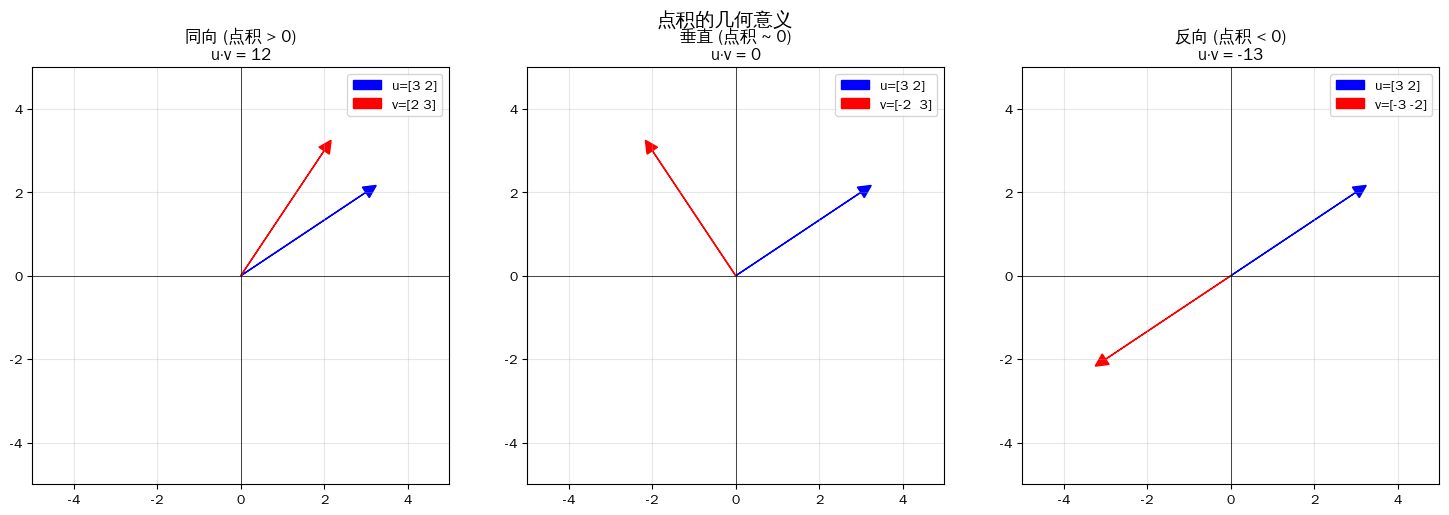

In [ ]:
# ===== 2.4 点积的几何意义可视化 =====
# plt.subplots()：matplotlib 用于一次性创建画布 + 多个子图的函数
# 1, 3：生成 1 行 3 列 共 3 个子图
# figsize=(15,5)：整个画布尺寸：宽 15 英寸、高 5 英寸
#
# 返回值
#     fig：整个画布对象（总容器）
#     axes：子图数组，长度为 3，axes[0]/axes[1]/axes[2]分别对应 3 个子图，用来分别绘图、设置样式
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

vectors = [
    ([3, 2], [2, 3], "同向 (点积 > 0)"),
    ([3, 2], [-2, 3], "垂直 (点积 ~ 0)"),
    ([3, 2], [-3, -2], "反向 (点积 < 0)"),
]

for ax, (u, v, title) in zip(axes, vectors):
    u, v = np.array(u), np.array(v)
    dot_val = np.dot(u, v)

    ax.arrow(0, 0, u[0], u[1], head_width=0.3, head_length=0.3, fc="blue", ec="blue", label=f"u={u}")
    ax.arrow(0, 0, v[0], v[1], head_width=0.3, head_length=0.3, fc="red", ec="red", label=f"v={v}")

    ax.set_xlim(-5, 5)
    ax.set_ylim(-5, 5)
    ax.axhline(y=0, color="k", linewidth=0.5)
    ax.axvline(x=0, color="k", linewidth=0.5)
    ax.set_aspect("equal")
    ax.legend()
    ax.set_title(f"{title}\nu·v = {dot_val}")
    ax.grid(True, alpha=0.3)

plt.suptitle("点积的几何意义", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


### 点积的几何解释

- **蓝色箭头** -> 向量 $\mathbf{u}$
- **红色箭头** -> 向量 $\mathbf{v}$
- **点积** -> $\mathbf{u} \cdot \mathbf{v}$

**关键理解**：点积反映了"一个向量在另一个向量方向上的投影长度 x 另一个向量的长度"。

这在机器学习中非常重要——例如，cosine similarity 就是归一化后的点积。


## 3. 矩阵运算

矩阵是线性代数的核心工具，在 ML 中无处不在——数据集、权重矩阵、协方差矩阵……

### 3.1 矩阵乘法
$$
\mathbf{C} = \mathbf{A}\mathbf{B}, \qquad
C_{ij} = \sum_k A_{ik}B_{kj}
$$

**核心规则**：$\mathbf{A}$ 的列数必须等于 $\mathbf{B}$ 的行数。
- 若 $\mathbf{A} \in \mathbb{R}^{m 	× n}$，$\mathbf{B} \in \mathbb{R}^{n 	× p}$，则 $\mathbf{C} \in \mathbb{R}^{m 	× p}$

### 3.2 转置
将矩阵的行列互换：
$$
(\mathbf{A}^T)_{ij} = A_{ji}
$$

### 3.3 逆矩阵
对于方阵 $\mathbf{A}$，若存在 $\mathbf{A}^{-1}$ 使得
$$
\mathbf{A}\mathbf{A}^{-1} = \mathbf{I}
$$
则称 $\mathbf{A}$ 可逆。

> **应用场景**：求解线性方程组 $\mathbf{x} = \mathbf{A}^{-1}\mathbf{b}$


In [18]:
# ===== 3.1 矩阵乘法 =====
A = np.array([
    [1, 2, 3],
    [4, 5, 6]
])  # 2x3

B = np.array([
    [7,  8],
    [9,  10],
    [11, 12]
])  # 3x2

print(f"矩阵 A 形状: {A.shape}")
print(f"矩阵 B 形状: {B.shape}")
print()

# 矩阵乘法: A @ B
C = A @ B
print(f"A @ B = C, 形状: {C.shape}")
print(C)

# 验证 C[0,0] = 1x7 + 2x9 + 3x11
print(f"验证 C[0,0] = 1x7 + 2x9 + 3x11 = {1*7 + 2*9 + 3*11}")
print(f"C[0,0] = {C[0, 0]} ✓")

# 逐元素乘法 (Hadamard积, 注意不是矩阵乘法!)
print(f"--- 注意区分 ---")
print(f"A * A (逐元素):{A * A}")


矩阵 A 形状: (2, 3)
矩阵 B 形状: (3, 2)

A @ B = C, 形状: (2, 2)
[[ 58  64]
 [139 154]]
验证 C[0,0] = 1x7 + 2x9 + 3x11 = 58
C[0,0] = 58 ✓
--- 注意区分 ---
A * A (逐元素):[[ 1  4  9]
 [16 25 36]]


In [19]:
# ===== 3.2 矩阵转置 =====
A = np.array([
    [1, 2, 3],
    [4, 5, 6]
])

A_T = A.T
print(f"A 形状: {A.shape}")
print(f"A:{A}")
print(f"A^T 形状: {A_T.shape}")
print(f"A^T:{A_T}")

# 转置的基本性质
B = np.random.randn(3, 4)
print(f"性质验证:")
print(f"(AB)^T == B^T A^T? {np.allclose((A @ B).T, B.T @ A.T)}")


A 形状: (2, 3)
A:[[1 2 3]
 [4 5 6]]
A^T 形状: (3, 2)
A^T:[[1 4]
 [2 5]
 [3 6]]
性质验证:
(AB)^T == B^T A^T? True


In [20]:
# ===== 3.3 逆矩阵 =====
A = np.array([
    [2, 1],
    [1, 3]
])

# 计算逆矩阵
A_inv = np.linalg.inv(A)
print(f"矩阵 A:{A}")
print(f"逆矩阵 A^(-1):{A_inv}")

# 验证 A @ A_inv ≈ I
I = A @ A_inv
print(f"A @ A^(-1):{np.round(I, 10)}")
print(f"是否为单位矩阵? {np.allclose(I, np.eye(2))}")

# ===== 不可逆矩阵 (奇异矩阵) =====
singular = np.array([
    [1, 2],
    [2, 4]  # 第二行是第一行的2倍
])
try:
    np.linalg.inv(singular)
except np.linalg.LinAlgError as e:
    print(f"奇异矩阵求逆失败: {e}")


矩阵 A:[[2 1]
 [1 3]]
逆矩阵 A^(-1):[[ 0.6 -0.2]
 [-0.2  0.4]]
A @ A^(-1):[[ 1.  0.]
 [-0.  1.]]
是否为单位矩阵? True
奇异矩阵求逆失败: Singular matrix


## 4. 线性方程组求解

线性方程组是许多 ML 问题的数学核心——线性回归、神经网络的前向传播等。

$$
\begin{cases}
2x + y = 5 \
x + 3y = 6
\end{cases}
$$

### 矩阵表示法
$$
\mathbf{A}\mathbf{x} = \mathbf{b}
\quad \Rightarrow \quad
\mathbf{x} = \mathbf{A}^{-1}\mathbf{b}
$$

### 求解方法对比
| 方法 | 适用场景 | 稳定性 |
|------|----------|--------|
| `np.linalg.inv(A) @ b` | 教学理解 | 低（额外计算） |
| `np.linalg.solve(A, b)` | 通用 | 高 |
| `np.linalg.lstsq(A, b)` | 超定方程（最小二乘） | 高 |

> **注意**：在实际应用中，应优先使用 `solve` 或 `lstsq`，避免显式求逆。


In [21]:
# ===== 4.1 使用 solve 直接求解 =====
# 方程组:
# 2x + y = 5
# x + 3y = 6

A = np.array([
    [2, 1],
    [1, 3]
])
b = np.array([5, 6])

# 方法一: np.linalg.solve (推荐!)
x = np.linalg.solve(A, b)
print(f"方程组 Ax = b")
print(f"A =\n{A}")
print(f"b = {b}")
print(f"解 x = {x}")
print()

# 验证
print(f"验证 Ax = {A @ x}")
print(f"是否等于 b? {np.allclose(A @ x, b)}")


方程组 Ax = b
A =
[[2 1]
 [1 3]]
b = [5 6]
解 x = [1.8 1.4]

验证 Ax = [5. 6.]
是否等于 b? True


拟合直线: y = 1.9739x + 1.1602
(真实关系: y = 2x + 1)


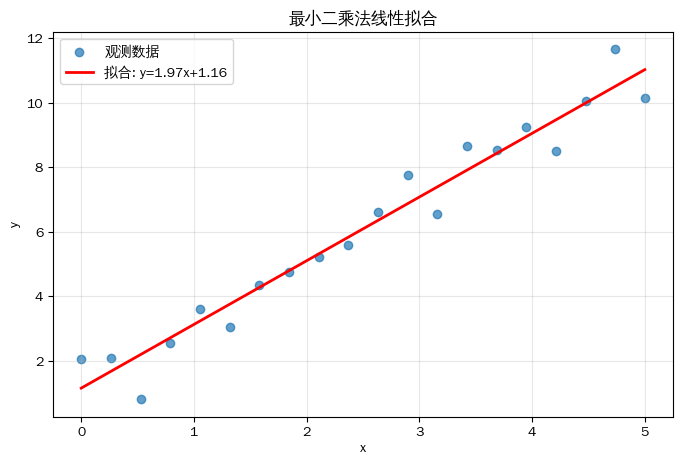

In [22]:
# ===== 4.2 最小二乘法 (超定方程组) =====
# 当方程数 > 未知数时，通常无精确解，用最小二乘找最佳近似

# 模拟: 用线性回归拟合数据
# 真实关系: y = 2x + 1 加上一些噪声

np.random.seed(10)
X_data = np.linspace(0, 5, 20)
y_data = 2 * X_data + 1 + np.random.randn(20) * 0.8

# 构建设计矩阵 [X, 1]
A = np.column_stack([X_data, np.ones(len(X_data))])

# 最小二乘求解: (A^T A)^-1 A^T b
result = np.linalg.lstsq(A, y_data, rcond=None)
coeffs = result[0]

print(f"拟合直线: y = {coeffs[0]:.4f}x + {coeffs[1]:.4f}")
print(f"(真实关系: y = 2x + 1)")

# 可视化
plt.figure(figsize=(8, 5))
plt.scatter(X_data, y_data, label='观测数据', alpha=0.7)
plt.plot(X_data, A @ coeffs, 'r-', linewidth=2, label=f'拟合: y={coeffs[0]:.2f}x+{coeffs[1]:.2f}')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.title('最小二乘法线性拟合')
plt.grid(True, alpha=0.3)
plt.show()


### 最小二乘法的原理

超定方程组 $\mathbf{A}\mathbf{x} = \mathbf{b}$ 无精确解时，我们寻找使残差平方和 $\lVert \mathbf{b} - \mathbf{A}\mathbf{x} \rVert^2$ 最小的解。

> **记号说明**
> - $\lVert \mathbf{b} - \mathbf{A}\mathbf{x} \rVert^2$：残差（真实值 - 预测值）的平方和
> - $\mathbf{x}^*$：最优解（使残差最小的 $\mathbf{x}$）

**正规方程**：
$$
\mathbf{x}^* = (\mathbf{A}^T\mathbf{A})^{-1}\mathbf{A}^T\mathbf{b}
$$

> **记号说明**
> - $\mathbf{A}^T$：$\mathbf{A}$ 的转置
> - $(\mathbf{A}^T\mathbf{A})^{-1}$：先计算 $\mathbf{A}^T\mathbf{A}$，再求逆

这正是线性回归的核心数学，也是机器学习中最基本的优化问题之一。


## 5. 特征值与特征向量

这是线性代数中最深刻也最实用的章节之一，在 PCA、PageRank、谱聚类等算法中扮演核心角色。

### 定义
对于方阵 $\mathbf{A}$，若存在非零向量 $\mathbf{v}$ 和标量 $\lambda$ 使得：

$$
\mathbf{A}\mathbf{v} = \lambda \mathbf{v}
$$

> **记号说明**
> - $\lambda$（lambda）：特征值，表示缩放因子
> - $\mathbf{v}$：特征向量，变换后方向不变的向量
> - $\mathbf{I}$：单位矩阵

则 $\lambda$ 称为**特征值**，$\mathbf{v}$ 称为**特征向量**。

### 几何意义
- 特征向量是指经过矩阵变换后**方向不变**的向量
- 特征值表示该方向上的**缩放因子**
- $\lambda > 1$：拉伸；$0 < \lambda < 1$：压缩；$\lambda < 0$：反向

### 求解步骤
1. 解特征方程 $\det(\mathbf{A} - \lambda\mathbf{I}) = 0$
> **记号说明**：$\det$ 表示行列式（determinant），$\det(\mathbf{A} - \lambda\mathbf{I}) = 0$ 是特征方程
2. 对每个 $\lambda$，求解 $(\mathbf{A} - \lambda\mathbf{I})\mathbf{v} = \mathbf{0}$


In [23]:
# ===== 5.1 特征值分解 =====
A = np.array([
    [4, 1],
    [2, 3]
])

# NumPy 直接求解
eigenvalues, eigenvectors = np.linalg.eig(A)

print(f"矩阵 A:\n{A}")
print(f"\n特征值 lambda = {eigenvalues}")
print(f"\n特征向量 (列向量):")
print(eigenvectors)

# 验证: A @ v = lambda * v
print("\n--- 验证 ---")
for i in range(len(eigenvalues)):
    v = eigenvectors[:, i]
    lam = eigenvalues[i]
    Av = A @ v
    lam_v = lam * v
    print(f"A @ v_{i} = {np.round(Av, 6)}")
    print(f"lambda_{i} * v_{i} = {np.round(lam_v, 6)}")
    print(f"相等? {np.allclose(Av, lam_v)}")
    print()


矩阵 A:
[[4 1]
 [2 3]]

特征值 lambda = [5. 2.]

特征向量 (列向量):
[[ 0.70710678 -0.4472136 ]
 [ 0.70710678  0.89442719]]

--- 验证 ---
A @ v_0 = [3.535534 3.535534]
lambda_0 * v_0 = [3.535534 3.535534]
相等? True

A @ v_1 = [-0.894427  1.788854]
lambda_1 * v_1 = [-0.894427  1.788854]
相等? True



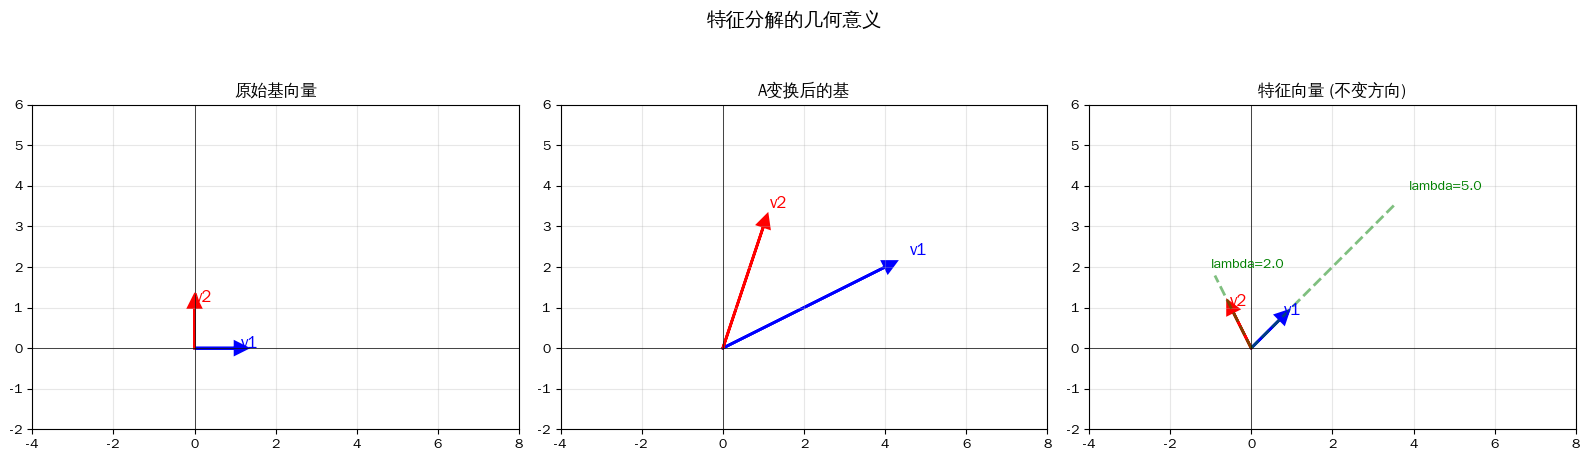

In [24]:
# ===== 5.2 特征分解的可视化 =====
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 原始基向量
basis = np.eye(2)

# 变换后的基向量
transformed = A @ basis

# 特征向量
eigvecs = eigenvectors

titles = ['原始基向量', 'A变换后的基', '特征向量 (不变方向)']
vector_sets = [
    (basis[:, 0], basis[:, 1]),
    (transformed[:, 0], transformed[:, 1]),
    (eigvecs[:, 0], eigvecs[:, 1]),
]

for ax, (v1, v2), title in zip(axes, vector_sets, titles):
    for v, color, label in [(v1, 'blue', 'v1'), (v2, 'red', 'v2')]:
        ax.arrow(0, 0, v[0], v[1], head_width=0.3, head_length=0.3,
                 fc=color, ec=color, linewidth=2)
        ax.text(v[0]*1.15, v[1]*1.15, label, fontsize=12, color=color)

    # 绘制特征值缩放示意
    if title == '特征向量 (不变方向)':
        for i, lam in enumerate(eigenvalues):
            v = eigvecs[:, i]
            end = lam * v
            ax.plot([0, end[0]], [0, end[1]], 'g--', alpha=0.5, linewidth=2)
            ax.text(end[0]*1.1, end[1]*1.1, f'lambda={lam:.1f}', fontsize=10, color='green')

    ax.set_xlim(-4, 8)
    ax.set_ylim(-2, 6)
    ax.axhline(y=0, color='k', linewidth=0.5)
    ax.axvline(x=0, color='k', linewidth=0.5)
    ax.set_aspect('equal')
    ax.set_title(title, fontsize=12)
    ax.grid(True, alpha=0.3)

plt.suptitle("特征分解的几何意义", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### 特征分解的应用

特征分解
$$
\mathbf{A} = \mathbf{V}\boldsymbol{\Lambda}\mathbf{V}^{-1}
$$
在机器学习中有重要应用：

- **PCA (主成分分析)**：数据协方差矩阵的特征向量 = 主成分方向
- **Google PageRank**：网页链接矩阵的主特征向量
- **谱聚类**：拉普拉斯矩阵的特征向量用于图分割

下面我们通过 PCA 实战来加深理解。


## 6. 实战应用：PCA 降维

**主成分分析 (PCA)** 是特征值分解的经典应用。核心思想：

1. 计算数据的协方差矩阵
2. 对协方差矩阵做特征分解
3. 取最大特征值对应的特征向量作为主成分
4. 将数据投影到主成分方向

> **记号说明**
> - **协方差矩阵**：描述多个变量之间的线性相关关系，元素 $C_{ij}$ 表示变量 $i$ 和 $j$ 的协方差
> - **主成分 (PC)**：特征值分解得到的特征向量方向，按特征值大小排序
> - **投影**：将数据点映射到主成分方向上的操作

### 直觉理解
- 找到数据中"方差最大"的方向 = 信息最丰富的方向
- 特征值大小 = 该方向上的方差
- 通过丢弃小特征值对应的方向实现降维


数据形状: (200, 2)
均值: [1.944 2.879]
协方差 (样本):
[[4.508 2.861]
 [2.861 2.268]]


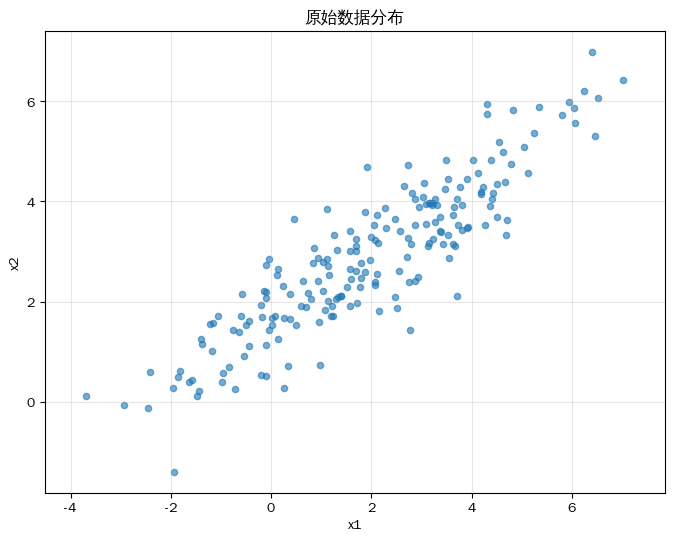

In [25]:
# ===== 6.1 生成示例数据 =====
np.random.seed(2023)

# 生成有相关性的二维数据 (椭圆分布)
mean = [2, 3]
cov = [[4, 2.5],
       [2.5, 2]]  # 正定协方差矩阵

data = np.random.multivariate_normal(mean, cov, 200)
print(f"数据形状: {data.shape}")
print(f"均值: {data.mean(axis=0).round(3)}")
print(f"协方差 (样本):")
print(np.round(np.cov(data.T), 3))

# 可视化原始数据
plt.figure(figsize=(8, 6))
plt.scatter(data[:, 0], data[:, 1], alpha=0.6, s=20)
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('原始数据分布')
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.show()


In [26]:
# ===== 6.2 PCA 核心步骤 (手动实现) =====
# Step 1: 数据中心化
data_centered = data - data.mean(axis=0)

# Step 2: 计算协方差矩阵
cov_matrix = np.cov(data_centered.T)
print(f"协方差矩阵:\n{cov_matrix}")

# Step 3: 特征分解
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

# 按特征值降序排列
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

print(f"\n特征值 (方差): {eigenvalues.round(4)}")
print(f"特征向量 (列):")
print(np.round(eigenvectors, 4))

# 解释方差比例
total_var = np.sum(eigenvalues)
explained = eigenvalues / total_var
print(f"\n解释方差比例: {explained.round(4)}")
print(f"第一主成分解释 {explained[0]*100:.1f}% 的方差")

# Step 4: 投影到主成分方向
projected = data_centered @ eigenvectors[:, 0]  # 只取第一主成分
print(f"\n投影后 (一维) 形状: {projected.shape}")


协方差矩阵:
[[4.50792963 2.86064725]
 [2.86064725 2.26770881]]

特征值 (方差): [6.4599 0.3157]
特征向量 (列):
[[ 0.826  -0.5636]
 [ 0.5636  0.826 ]]

解释方差比例: [0.9534 0.0466]
第一主成分解释 95.3% 的方差

投影后 (一维) 形状: (200,)


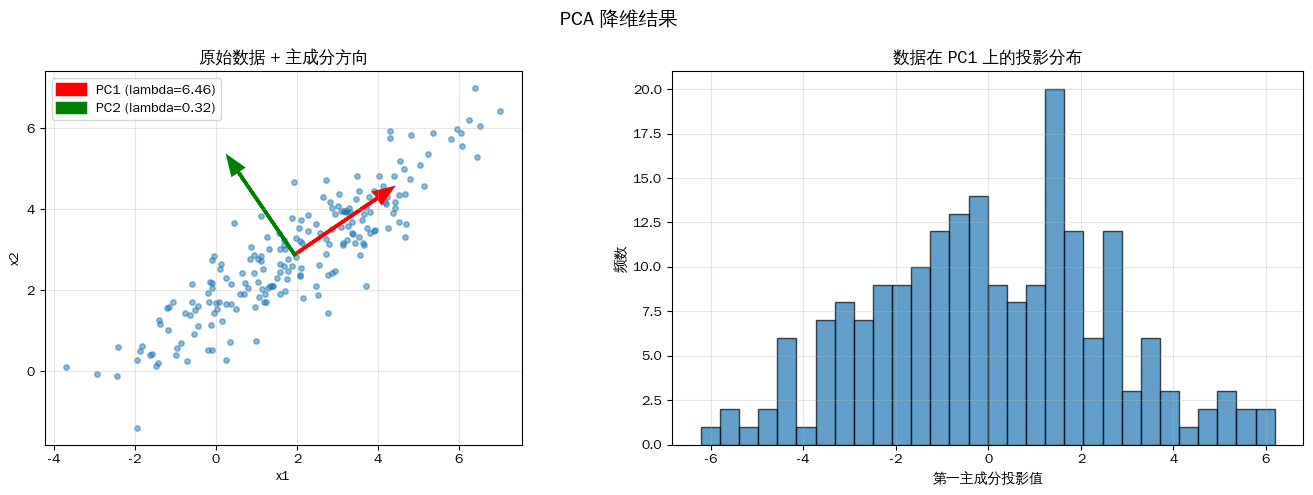

降维后数据保留信息: 95.3%
从 2D -> 1D, 压缩率: 50%, 信息损失仅 4.7%


In [27]:
# ===== 6.3 PCA 结果可视化 =====
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左图: 原始数据 + 主成分方向
ax1 = axes[0]
ax1.scatter(data[:, 0], data[:, 1], alpha=0.5, s=15)

# 绘制特征向量 (主成分方向)
origin = data.mean(axis=0)
scale = 2.5  # 放大箭头以便观察
for i, color, label in [(0, "red", f"PC1 (lambda={eigenvalues[0]:.2f})"),
                          (1, "green", f"PC2 (lambda={eigenvalues[1]:.2f})")]:
    v = eigenvectors[:, i]
    ax1.arrow(origin[0], origin[1],
              scale*v[0], scale*v[1],
              head_width=0.3, head_length=0.4,
              fc=color, ec=color, linewidth=2.5, label=label)

ax1.set_aspect("equal")
ax1.set_xlabel("x1")
ax1.set_ylabel("x2")
ax1.set_title("原始数据 + 主成分方向")
ax1.legend()
ax1.grid(True, alpha=0.3)

# 右图: 投影到一维后的分布
ax2 = axes[1]
ax2.hist(projected, bins=30, edgecolor="black", alpha=0.7)
ax2.set_xlabel("第一主成分投影值")
ax2.set_ylabel("频数")
ax2.set_title("数据在 PC1 上的投影分布")
ax2.grid(True, alpha=0.3)

plt.suptitle("PCA 降维结果", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"降维后数据保留信息: {explained[0]*100:.1f}%")
print(f"从 2D -> 1D, 压缩率: 50%, 信息损失仅 {100 - explained[0]*100:.1f}%")


## 7. 总结与扩展

### 关键知识点回顾

| 概念 | 核心公式 | ML 中的应用 |
|------|----------|-------------|
| 向量点积 | $\mathbf{u}\cdot\mathbf{v} = \sum_i u_i v_i$ | 相似度计算、注意力机制 |
| 矩阵乘法 | $C_{ij} = \sum_k A_{ik}B_{kj}$ | 神经网络前向传播 |
| 逆矩阵 | $\mathbf{A}\mathbf{A}^{-1} = \mathbf{I}$ | 线性方程组求解 |
| 最小二乘 | $\mathbf{x}^* = (\mathbf{A}^T\mathbf{A})^{-1}\mathbf{A}^T\mathbf{b}$ | 线性回归 |
| 特征分解 | $\mathbf{A} = \mathbf{V}\boldsymbol{\Lambda}\mathbf{V}^{-1}$ | PCA、PageRank |

> **记号速查**
> - $\mathbb{R}$：实数集
> - $\mathbf{v}$：向量（粗体小写）
> - $\mathbf{A}$：矩阵（粗体大写）
> - $\lambda$：特征值
> - $\mathbf{I}$：单位矩阵
> - $\mathbf{V}^{-1}$：矩阵逆
> - $\mathbf{A}^T$：矩阵转置
> - $\lVert \mathbf{v} \rVert$：向量范数（长度）
> - $\sum_i$：求和符号
> - $\det(\mathbf{A})$：行列式

### 延伸学习方向
1. **SVD 奇异值分解** — 比特征分解更通用的矩阵分解方法
2. **矩阵求导** — 深度学习反向传播的数学基础
3. **概率图模型** — 信息论与图论的结合

> **推荐练习**：尝试用 NumPy 从零实现一个简单的线性回归（不使用 sklearn）。
